# SIMILIS - Data-Centric Description of Archaeological Artifacts
## Corpus analysis, active learning, data-centric improvement
#### `форматирование выводов, построение графиков, нормализация текстовых меток сгенерированы LLM`

## 1. Окружение

In [ ]:

import os, sys, random, warnings, json, csv
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()} | device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from google.colab import drive
drive.mount('/content/drive')
import zipfile
from pathlib import Path


Python : 3.12.13
PyTorch: 2.10.0+cu128
CUDA   : True | device: Tesla T4
Device: cuda
Mounted at /content/drive


In [ ]:

DATA_DIR = Path("/content/drive/MyDrive/CU_4/SIMILIS")
IMG_DIR  = DATA_DIR / "dataset"

if not IMG_DIR.exists():
    print("Распаковываем dataset.zip ...")
    with zipfile.ZipFile(DATA_DIR / "dataset.zip") as z:
        z.extractall(DATA_DIR)
    print(f"Готово: {len(list(IMG_DIR.glob('*.jpg')))} изображений")
else:
    print(f"Уже распаковано: {len(list(IMG_DIR.glob('*.jpg')))} изображений")
# DATA_DIR = Path(r""" + f'"{DATA_DIR}"' + r""")
# IMG_DIR  = Path(r""" + f'"{IMG_DIR}"' + r""")
# CSV_PATH = Path(r""" + f'"{CSV_PATH}"' + r""")

PROJECT_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()

dirs = [
    "data/raw", "data/interim", "data/processed",
    "splits",
    "artifacts/checkpoints", "artifacts/preds",
    "artifacts/reports", "artifacts/review",
    "artifacts/active_learning",
]
for d in dirs:
    (PROJECT_DIR / d).mkdir(parents=True, exist_ok=True)

print("\nDirectory structure created:")
for d in dirs:
    print(f"  ✓ {d}")

Уже распаковано: 1359 изображений

Directory structure created:
  ✓ data/raw
  ✓ data/interim
  ✓ data/processed
  ✓ splits
  ✓ artifacts/checkpoints
  ✓ artifacts/preds
  ✓ artifacts/reports
  ✓ artifacts/review
  ✓ artifacts/active_learning


## 2. Загрузка данных и пулы

In [ ]:
CSV_PATH = DATA_DIR / "selected_by_name_iimk_subset_public.csv"

In [ ]:

df_all = pd.read_csv(CSV_PATH, index_col=0)
df_all["image_file"] = df_all["code"].astype(str) + "_orig.jpg"
df_all["image_path"] = df_all["image_file"].apply(lambda f: IMG_DIR / f)
df_all["image_exists"] = df_all["image_path"].apply(lambda p: p.exists())

# group_key - префикс кода (до последнего '-NNNN')
# объединяет несколько ракурсов одного артефакта
df_all["group_key"] = df_all["code"].str.rsplit("-", n=1).str[0]

print("Total records in CSV :", len(df_all))
print("Images found on disk  :", df_all["image_exists"].sum())
print("Missing images        :", (~df_all["image_exists"]).sum())
print("Unique group_keys     :", df_all["group_key"].nunique())
print("\nColumns:", df_all.columns.tolist())
print("\nSample:\n", df_all.head(3))


Total records in CSV : 1389
Images found on disk  : 1358
Missing images        : 31
Unique group_keys     : 75

Columns: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear', 'image_file', 'image_path', 'image_exists', 'group_key']

Sample:
                 code     name  \
40  М102-2012-1-0494  Изразец   
41  М102-2012-1-0496  Изразец   
49  М102-2012-1-0529  Изразец   

                                                                        description  \
40  Изразца красноглиняного с белой поливой и кобальтовой (растительной либо сюж...   
41         Изразца красноглиняного плоского с белой поливой и голубой росписью фр-т   
49  Изразца-перемычки красноглиняного с белой поливой и кобальтовой растительной...   

    material                   size     fragm               cultlayer  \
40  Керамика    7+ х 3,5+ х 1,1+ см  Фрагмент  Пестрая мешаная супесь   
41  Керамика  9,9+ х 6,4+ х 1,3+ см  Фрагмент  Пестрая мешаная супесь   
49  Керамика  

In [ ]:
df_valid = df_all[df_all["image_exists"]].reset_index(drop=True)
print(f"Valid dataset size: {len(df_valid)}")

groups = df_valid["group_key"].unique()
np.random.shuffle(groups)

n = len(groups)
n_seed    = int(n * 0.50)   # 50%  train_seed
n_val     = int(n * 0.15)   # 15%  val_gold
n_test    = int(n * 0.15)   # 15%  test_gold


seed_groups  = set(groups[:n_seed])
val_groups   = set(groups[n_seed:n_seed + n_val])
test_groups  = set(groups[n_seed + n_val:n_seed + n_val + n_test])
pool_groups  = set(groups[n_seed + n_val + n_test:])

# метка разбивки на строку
def assign_split(gk):
    if gk in seed_groups: return "train_seed"
    if gk in val_groups:  return "val_gold"
    if gk in test_groups: return "test_gold"
    return "pool_candidate"

df_valid["split"] = df_valid["group_key"].apply(assign_split)

split_counts = df_valid.groupby("split").size()
print("\nSplit sizes (rows):")
print(split_counts)
print("\nSplit sizes (groups):")
for name, grps in [("train_seed", seed_groups), ("val_gold", val_groups),
                   ("test_gold", test_groups), ("pool_candidate", pool_groups)]:
    print(f"  {name:18s}: {len(grps):4d} groups")


Valid dataset size: 1358

Split sizes (rows):
split
pool_candidate    439
test_gold         130
train_seed        673
val_gold          116
dtype: int64

Split sizes (groups):
  train_seed        :   37 groups
  val_gold          :   11 groups
  test_gold         :   11 groups
  pool_candidate    :   15 groups


In [ ]:
print(list(DATA_DIR.iterdir()))

[PosixPath('/content/drive/MyDrive/CU_4/SIMILIS/selected_by_name_iimk_subset_public.csv'), PosixPath('/content/drive/MyDrive/CU_4/SIMILIS/dataset')]


## 3. Валидация таблицы

In [ ]:

print("=== Column types ===")
print(df_all.dtypes)
print("\n=== Missing per column ===")
print(df_all.isnull().sum())

dup_imgs = df_all["image_file"].duplicated().sum()
print(f"\nDuplicate image_file entries: {dup_imgs}")

dup_codes = df_all["code"].duplicated().sum()
print(f"Duplicate code entries      : {dup_codes}")

print(f"\nValid image paths : {df_all['image_exists'].sum()}")
print(f"Broken image paths: {(~df_all['image_exists']).sum()}")

# group_key дублируется - несколько ракурсов одного объекта
gk_counts = df_valid["group_key"].value_counts()
print(f"\nmax images per group_key : {gk_counts.max()}")
print(f"mean images per group_key: {gk_counts.mean():.1f}")
print(f"groups with >1 image     : {(gk_counts > 1).sum()}")


=== Column types ===
code             object
name             object
description      object
material         object
size             object
fragm            object
cultlayer        object
execorg          object
survyear        float64
image_file       object
image_path       object
image_exists       bool
group_key        object
dtype: object

=== Missing per column ===
code              0
name              0
description       2
material          0
size            183
fragm             2
cultlayer       110
execorg         936
survyear        858
image_file        0
image_path        0
image_exists      0
group_key         0
dtype: int64

Duplicate image_file entries: 1
Duplicate code entries      : 1

Valid image paths : 1358
Broken image paths: 31

max images per group_key : 236
mean images per group_key: 18.4
groups with >1 image     : 61


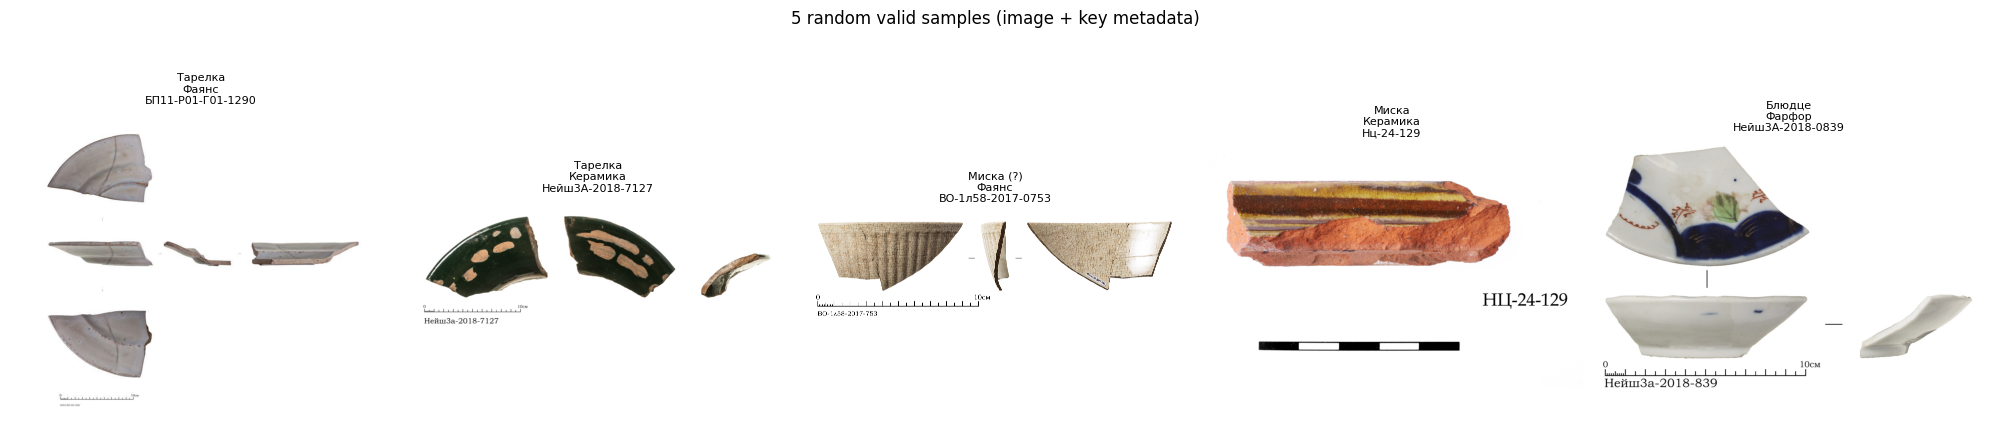

In [ ]:

samples = df_valid[df_valid["image_exists"]].sample(5, random_state=SEED)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (_, row) in zip(axes, samples.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(f"{row['name']}\n{row['material']}\n{row['code'][:20]}", fontsize=8)
    ax.axis("off")
plt.suptitle("5 random valid samples (image + key metadata)", fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/sample_images.png", dpi=100)
plt.show()


## 4. Разведочный анализ

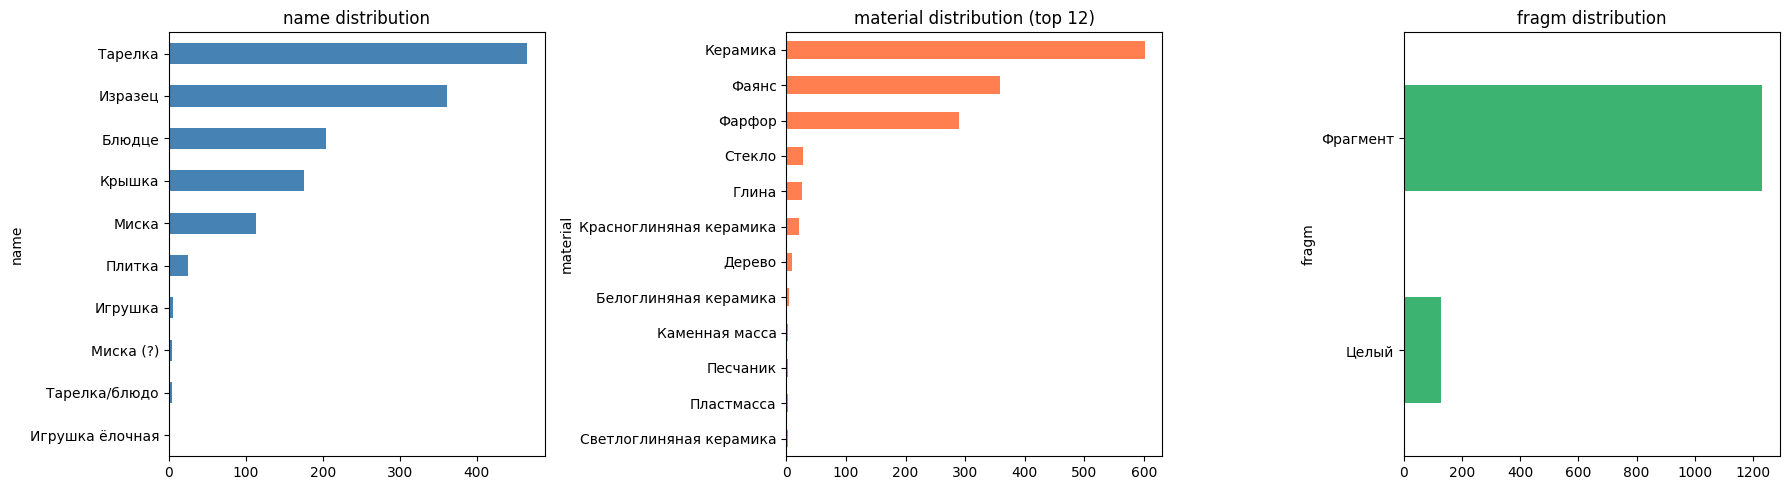

name classes : {'Тарелка': 465, 'Изразец': 361, 'Блюдце': 204, 'Крышка': 176, 'Миска': 113, 'Плитка': 25, 'Игрушка': 5, 'Миска (?)': 4, 'Тарелка/блюдо': 4, 'Игрушка ёлочная': 1}
material top : {'Керамика': 601, 'Фаянс': 359, 'Фарфор': 289, 'Стекло': 28, 'Глина': 26, 'Красноглиняная керамика': 21, 'Дерево': 9, 'Белоглиняная керамика': 4}


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vc_name = df_valid["name"].value_counts()
vc_name.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("name distribution")
axes[0].invert_yaxis()

vc_mat = df_valid["material"].value_counts()
vc_mat.head(12).plot.barh(ax=axes[1], color="coral")
axes[1].set_title("material distribution (top 12)")
axes[1].invert_yaxis()

vc_fragm = df_valid["fragm"].value_counts()
vc_fragm.plot.barh(ax=axes[2], color="mediumseagreen")
axes[2].set_title("fragm distribution")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/field_distributions.png", dpi=100)
plt.show()

print("name classes :", vc_name.to_dict())
print("material top :", vc_mat.head(8).to_dict())


In [ ]:

suspicious_name = df_valid[df_valid["name"].str.contains(r"\?", na=False)]
print(f"Names with '?' (tentative): {len(suspicious_name)}")
print(suspicious_name[["code", "name", "material", "description"]].head(5))

print("\n=== All unique materials ===")
for m in sorted(df_valid["material"].unique()):
    print(f"  {m}: {(df_valid['material'] == m).sum()}")

unc_desc = df_valid[df_valid["description"].str.contains(r"\?", na=False)]
print(f"\nDescriptions with '?' : {len(unc_desc)}")
print(unc_desc[["code", "name", "description"]].head(5))

print(f"\nRare name classes (≤5 samples):")
print(vc_name[vc_name <= 5])


Names with '?' (tentative): 4
                   code       name  material  \
43     М102-2012-2-1423  Миска (?)  Керамика   
1231  ВО-1л58-2017-0124  Миска (?)  Керамика   
1254  ВО-1л58-2017-0441  Миска (?)  Керамика   
1311  ВО-1л58-2017-0753  Миска (?)     Фаянс   

                                                                          description  
43    Сосуда (миски ?) красноглиняного со следами желто-зеленой поливы внутри венч...  
1231  Сосуда (миски ?) красноглиняной  с прозрачной бесцветной поливой внутри венч...  
1254                                    Сосуда (миски ?) красноглиняного венчика фр-т  
1311      Сосуда (миски ?) фаянсовой  с бежевой поливой внутри и снаружи венчика фр-т  

=== All unique materials ===
  Белоглиняная керамика: 4
  Белый металл: 1
  Бронза: 1
  Глина: 26
  Гранит: 1
  Дерево: 9
  Каменная масса: 3
  Камень: 1
  Керамика: 601
  Красноглиняная керамика: 21
  Металл: 1
  Основание - бетон, покрытие - композитный материал: 2
  Песчаник: 3
  Плас

Analyzing image sample (N=200) ...


100%|██████████| 200/200 [04:04<00:00,  1.22s/it]


         fg_ratio      aspect
count  199.000000  199.000000
mean     0.309709    1.407050
std      0.096090    0.751457
min      0.086000    0.283000
25%      0.243500    0.800000
50%      0.307000    1.268000
75%      0.368000    1.886000
max      0.673000    3.629000

layout_mode counts:
layout_mode
single-view    121
multi-view      78
Name: count, dtype: int64

size counts:
size
large     173
medium     26
Name: count, dtype: int64


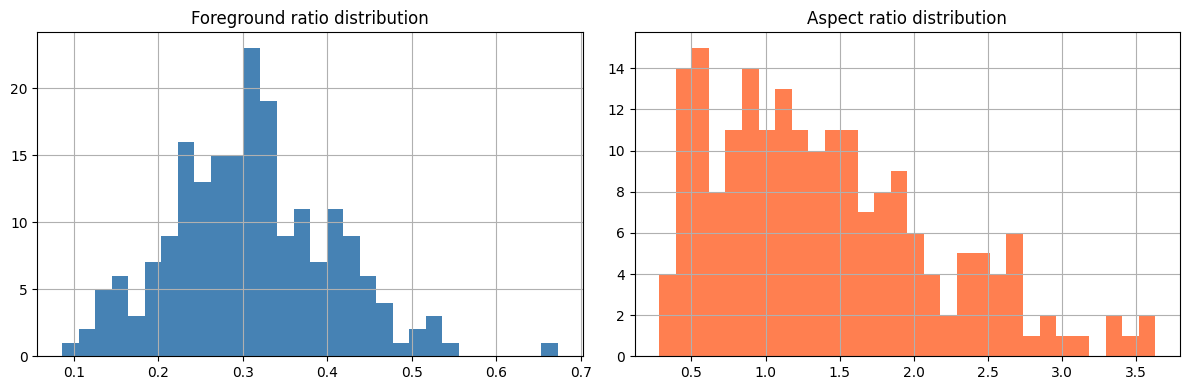

In [ ]:
def analyze_image(path):
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        h, w = arr.shape[:2]

        # доля белого фона
        white_mask = np.all(arr > 240, axis=2)
        bg_ratio = white_mask.mean()
        fg_ratio = 1.0 - bg_ratio

        aspect = w / h

        size_cat = "large" if max(h, w) > 2000 else "medium" if max(h, w) > 800 else "small"

        # multi-view: широкие / высокие карточки
        layout = "multi-view" if (aspect > 1.8 or aspect < 0.55) else "single-view"

        return {"fg_ratio": round(fg_ratio, 3), "aspect": round(aspect, 3),
                "layout_mode": layout, "bg_type": "white", "size": size_cat,
                "has_scale_bar": fg_ratio > 0.05,
                }
    except Exception:
        return None

print("Analyzing image sample (N=200) ...")
sample_paths = df_valid[df_valid["image_exists"]]["image_path"].sample(200, random_state=SEED)
analyses = [analyze_image(p) for p in tqdm(sample_paths)]
analyses = [a for a in analyses if a is not None]
df_vis = pd.DataFrame(analyses)

print(df_vis.describe())
print("\nlayout_mode counts:")
print(df_vis["layout_mode"].value_counts())
print("\nsize counts:")
print(df_vis["size"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_vis["fg_ratio"].hist(bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Foreground ratio distribution")
df_vis["aspect"].hist(bins=30, ax=axes[1], color="coral")
axes[1].set_title("Aspect ratio distribution")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/visual_nuisance.png", dpi=100)
plt.show()


Выводы:
- Изображения - карточки с несколькими проекциями

- Доля объекта на снимке варьируется от 0.03 до 0.60 - некоторые объекты едва видны в кадре

- На всех фото есть линейка. Модель может выучить ложную связь: линейка -> керамика

- Крупные планы на одной карточке выглядят как разные объекты, но имеют одну метку. Это создаёт визуальный шум в разметке

- Снимки с долей объекта ниже 0.05 - это почти пустой фон плюс линейка. Они сложны не из-за ошибок в метках, а из-за плохой компоновки

## 5. Целевые поля и гипотезы

In [ ]:

field_table = pd.DataFrame([
    {
        "field_name": "name",
        "rationale": "Primary visual signal - shape/form is directly observable",
        "class_count": df_valid["name"].nunique(),
        "missing_rate": df_valid["name"].isnull().mean(),
        "noise_sources": "Tentative '(?)', borderline Тарелка/Блюдо, rare Игрушка",
        "why_baseline_fails": "Multi-view layout: tile fragment and close-up look different",
    },
    {
        "field_name": "material",
        "rationale": "Texture/glaze visible: Фаянс vs Фарфор vs Керамика differ visually",
        "class_count": df_valid["material"].nunique(),
        "missing_rate": df_valid["material"].isnull().mean(),
        "noise_sources": "Synonyms: Красноглиняная керамика vs Керамика; rare classes",
        "why_baseline_fails": "Without label normalization, 21 classes instead of 5",
    },
])
print(field_table.to_string())


гипотезы:

- H1: Нормализация словаря материалов (объединение "Красноглиняная керамика" → "Керамика") даст больший прирост F1 по материалу, чем переход с EfficientNet-B0 на B3

- H2: Выборка по неопределённости (на основе энтропии) при бюджете B=50 работает лучше случайной на нормализованном поле "название", но при B=100 преимущество исчезает из-за насыщения

- H3: Значительная часть предсказаний с низкой уверенностью приходится на многопроекционные карточки с очень малой долей объекта (< 0.10), а не на настоящий шум в разметке — иначе говоря, артефакты компоновки маскируются под "сложные примеры"

## 6. Нормализация меток

In [ ]:

NAME_NORM = {
    "Тарелка": "Тарелка",
    "Тарелка/блюдо": "Тарелка",
    "Изразец": "Изразец",
    "Блюдце": "Блюдце",
    "Крышка": "Крышка",
    "Миска": "Миска",
    "Миска (?)": "UNCERTAIN",
    "Плитка": "Плитка",
    "Игрушка": "Игрушка",
    "Игрушка ёлочная": "Игрушка",
}

MATERIAL_NORM = {
    "Керамика": "Керамика",
    "Красноглиняная керамика": "Керамика",
    "Белоглиняная керамика": "Керамика",
    "Светлоглиняная керамика": "Керамика",
    "Серолощеная керамика": "Керамика",
    "Глина": "Керамика",
    "Фаянс": "Фаянс",
    "Фарфор": "Фарфор",
    "Стекло": "Стекло",
    "Каменная масса": "Каменная масса",
    "Дерево": "RARE",
    "Камень": "RARE",
    "Песчаник": "RARE",
    "Сланец": "RARE",
    "Гранит": "RARE",
    "Бронза": "RARE",
    "Металл": "RARE",
    "Белый металл": "RARE",
    "Пластмасса": "RARE",
    "Резина": "RARE",
    "Основание - бетон, покрытие - композитный материал": "RARE",
}

df_valid = df_valid.copy()
df_valid["raw_name"]     = df_valid["name"]
df_valid["norm_name"]    = df_valid["name"].map(NAME_NORM).fillna("RARE")
df_valid["raw_material"] = df_valid["material"]
df_valid["norm_material"]= df_valid["material"].map(MATERIAL_NORM).fillna("RARE")
df_valid["label_is_uncertain"] = (
    df_valid["norm_name"].eq("UNCERTAIN") |
    df_valid["description"].str.contains(r"\?", na=False)
)
df_valid["label_is_missing"] = df_valid["name"].isnull()
df_valid["quality_flag"] = "ok"
df_valid.loc[df_valid["label_is_uncertain"], "quality_flag"] = "uncertain"
df_valid.loc[df_valid["norm_name"] == "RARE",  "quality_flag"] = "rare_class"
df_valid.loc[df_valid["norm_material"] == "RARE", "quality_flag"] = "rare_class"

print("=== name before normalization ===")
print(df_valid["raw_name"].value_counts())
print("\n=== name after normalization ===")
print(df_valid["norm_name"].value_counts())
print("\n=== material before normalization ===")
print(df_valid["raw_material"].value_counts().head(12))
print("\n=== material after normalization ===")
print(df_valid["norm_material"].value_counts())
print("\n=== quality_flag counts ===")
print(df_valid["quality_flag"].value_counts())


=== name before normalization ===
raw_name
Тарелка            465
Изразец            361
Блюдце             204
Крышка             176
Миска              113
Плитка              25
Игрушка              5
Миска (?)            4
Тарелка/блюдо        4
Игрушка ёлочная      1
Name: count, dtype: int64

=== name after normalization ===
norm_name
Тарелка      469
Изразец      361
Блюдце       204
Крышка       176
Миска        113
Плитка        25
Игрушка        6
UNCERTAIN      4
Name: count, dtype: int64

=== material before normalization ===
raw_material
Керамика                   601
Фаянс                      359
Фарфор                     289
Стекло                      28
Глина                       26
Красноглиняная керамика     21
Дерево                       9
Белоглиняная керамика        4
Каменная масса               3
Песчаник                     3
Пластмасса                   2
Светлоглиняная керамика      2
Name: count, dtype: int64

=== material after normalization ===
norm_ma

In [ ]:

PROCESSED = PROJECT_DIR / "data/processed"
df_valid.to_csv(PROCESSED / "working_table.csv", index=False)
print(f"Saved to {PROCESSED / 'working_table.csv'}")

# убрать uncertain и редкие классы
KEEP_NAMES = [k for k, v in NAME_NORM.items() if v not in ("UNCERTAIN", "RARE")]
KEEP_MATS  = ["Керамика", "Фаянс", "Фарфор", "Стекло", "Каменная масса"]

df_clean = df_valid[
    df_valid["norm_name"].isin(KEEP_NAMES) &
    df_valid["norm_material"].isin(KEEP_MATS)
].copy().reset_index(drop=True)

print(f"\nClean corpus size: {len(df_clean)} (from {len(df_valid)} valid)")
print(f"Name classes: {sorted(df_clean['norm_name'].unique())}")
print(f"Material classes: {sorted(df_clean['norm_material'].unique())}")

df_clean.to_csv(PROCESSED / "clean_corpus.csv", index=False)


Saved to /content/data/processed/working_table.csv

Clean corpus size: 1330 (from 1358 valid)
Name classes: ['Блюдце', 'Игрушка', 'Изразец', 'Крышка', 'Миска', 'Плитка', 'Тарелка']
Material classes: ['Каменная масса', 'Керамика', 'Стекло', 'Фарфор', 'Фаянс']


## Аугментация описаний

Генерация синонимичных описаний через шаблонную замену и словарь синонимов. ~1120 → ~5600 пар без семантического шума.

In [ ]:

import re
from itertools import product

class DescriptionAugmenter:
    """Генератор синонимичных описаний"""

    # синонимы
    SYNONYMS = {
        "фр-т": ["фрагмент", "обломок", "фр."],
        "Фрагмент": ["Фр-т", "Обломок"],
        "Целый": ["Целый экземпляр", "Полностью сохранился", "В целом виде"],
        "белой поливой": ["белой глазурью", "белым поливом", "белой поверхностной поливой"],
        "синей росписью": ["синей декоративной росписью", "росписью синего цвета", "синим орнаментом"],
        "кобальтовой росписью": ["кобальтовым декором", "росписью кобальтом", "синей кобальтовой росписью"],
        "растительной": ["растительным", "флоральным", "с растительным мотивом"],
        "красноглиняного": ["из красной глины", "красноглиняный", "из красноглиняной массы"],
        "белоглиняного": ["из белой глины", "белоглиняный"],
        "полива": ["глазурь", "полив", "покрытие поливой"],
        "поливой": ["глазурью", "поливой", "глазурным покрытием"],
    }

    TEMPLATES = {
        "Тарелка": [
            "{desc_raw}",
            "Фрагмент тарелки. Материал: {material}. {extra}",
            "Тарелка ({material_adj}){deco}. {fragm_status}.",
        ],
        "Изразец": [
            "{desc_raw}",
            "Фрагмент изразца из {material_noun}. {deco}.",
            "Изразец ({material_adj}){deco}. Состояние: {fragm_status}.",
        ],
        "Блюдце": [
            "{desc_raw}",
            "Фрагмент блюдца ({material_adj}){deco}.",
        ],
        "Крышка": [
            "{desc_raw}",
            "Крышка из {material_noun}{deco}. {fragm_status}.",
        ],
        "Миска": [
            "{desc_raw}",
            "Миска ({material_adj}){deco}. Состояние: {fragm_status}.",
        ],
        "Плитка": [
            "{desc_raw}",
            "Плитка из {material_noun}{deco}. {fragm_status}.",
        ],
    }

    MATERIAL_ADJ = {
        "Керамика": "керамическая",
        "Фаянс": "фаянсовая",
        "Фарфор": "фарфоровая",
        "Стекло": "стеклянная",
        "Каменная масса": "из каменной массы",
    }
    MATERIAL_NOUN = {
        "Керамика": "керамики",
        "Фаянс": "фаянса",
        "Фарфор": "фарфора",
        "Стекло": "стекла",
        "Каменная масса": "каменной массы",
    }

    def _apply_synonyms(self, text: str) -> list:
        """ вернёт список текстов, выполнив одну замену на синоним за проход."""
        variants = [text]
        for term, alts in self.SYNONYMS.items():
            if term in text:
                for alt in alts:
                    variants.append(text.replace(term, alt, 1))
        return list(set(variants))

    def augment_description(self, row: dict, n: int = 4) -> list:
        """генерирует n описаний"""
        name     = str(row.get("norm_name", row.get("name", "")))
        material = str(row.get("norm_material", row.get("material", "")))
        fragm    = str(row.get("fragm", ""))
        desc_raw = str(row.get("description", ""))

        fill = {
            "desc_raw": desc_raw,
            "material": material,
            "material_adj": self.MATERIAL_ADJ.get(material, material.lower()),
            "material_noun": self.MATERIAL_NOUN.get(material, material.lower()),
            "fragm_status": fragm,
            "deco": "",
            "extra": "",
        }
        templates = self.TEMPLATES.get(name, ["{desc_raw}"])
        filled = []
        for tmpl in templates:
            try:
                filled.append(tmpl.format(**fill))
            except KeyError:
                filled.append(desc_raw)

        syns = self._apply_synonyms(desc_raw)
        candidates = filled + syns
        seen, out = set(), []
        for c in candidates:
            c = c.strip()
            if c and c not in seen:
                seen.add(c)
                out.append(c)
            if len(out) >= n:
                break
        return out if out else [desc_raw]


aug = DescriptionAugmenter()

# пример выведу
sample_rows = df_clean.head(3).to_dict("records")
for row in sample_rows:
    print(f"\n[{row['code']}] {row['name']} / {row['norm_material']}")
    print(f"  ORIGINAL: {row['description']}")
    for i, d in enumerate(aug.augment_description(row, n=4), 1):
        print(f"  VAR {i}   : {d}")



[М102-2012-1-0494] Изразец / Керамика
  ORIGINAL: Изразца красноглиняного с белой поливой и кобальтовой (растительной либо сюжетной ?) росписью фр-т
  VAR 1   : Изразца красноглиняного с белой поливой и кобальтовой (растительной либо сюжетной ?) росписью фр-т
  VAR 2   : Фрагмент изразца из керамики. .
  VAR 3   : Изразец (керамическая). Состояние: Фрагмент.
  VAR 4   : Изразца красноглиняного с белой поливой и кобальтовой (растительной либо сюжетной ?) росписью обломок

[М102-2012-1-0496] Изразец / Керамика
  ORIGINAL: Изразца красноглиняного плоского с белой поливой и голубой росписью фр-т
  VAR 1   : Изразца красноглиняного плоского с белой поливой и голубой росписью фр-т
  VAR 2   : Фрагмент изразца из керамики. .
  VAR 3   : Изразец (керамическая). Состояние: Фрагмент.
  VAR 4   : Изразца красноглиняного плоского с белой поливой и голубой росписью фрагмент

[М102-2012-1-0529] Изразец / Керамика
  ORIGINAL: Изразца-перемычки красноглиняного с белой поливой и кобальтовой растительн

In [ ]:
# N вариантов описания на изображение

augmented_records = []
train_rows = df_clean[df_clean["split"] == "train_seed"].to_dict("records")

for row in tqdm(train_rows, desc="Augmenting descriptions"):
    descs = aug.augment_description(row, n=4)
    for i, d in enumerate(descs):
        rec = dict(row)
        rec["aug_description"] = d
        rec["aug_idx"] = i
        augmented_records.append(rec)

df_aug = pd.DataFrame(augmented_records)
df_aug.to_csv(PROCESSED / "train_augmented.csv", index=False)
print(f"Augmented training set: {len(df_aug)} rows (from {len(train_rows)} originals)")
print(f"Expansion factor: {len(df_aug)/len(train_rows):.1f}x")


Augmenting descriptions: 100%|██████████| 655/655 [00:00<00:00, 68032.02it/s]

Augmented training set: 2446 rows (from 655 originals)
Expansion factor: 3.7x


## 7. Протокол и разбивки

In [ ]:
# Разбивки из шага 2, фиксируем на диск

SPLITS_DIR = PROJECT_DIR / "splits"

for split_name in ["train_seed", "val_gold", "test_gold", "pool_candidate"]:
    subset = df_clean[df_clean["split"] == split_name]
    subset[["code", "image_file", "group_key", "norm_name", "norm_material",
            "fragm", "quality_flag"]].to_csv(
        SPLITS_DIR / f"{split_name}.csv", index=False)
    print(f"{split_name:18s}: {len(subset):5d} images, "
          f"{subset['group_key'].nunique():4d} groups")

sets = {s: set(df_clean[df_clean["split"] == s]["group_key"])
        for s in ["train_seed", "val_gold", "test_gold", "pool_candidate"]}

print("\n=== Group leakage check (all should be 0) ===")
split_list = list(sets.keys())
for i in range(len(split_list)):
    for j in range(i + 1, len(split_list)):
        a, b = split_list[i], split_list[j]
        overlap = sets[a] & sets[b]
        print(f"  {a} ∩ {b} = {len(overlap)}")

multi_view_groups = (df_clean.groupby("group_key")
                    .size()
                    .sort_values(ascending=False)
                    .head(3)
                    .index.tolist())

for gk in multi_view_groups:
    rows = df_clean[df_clean["group_key"] == gk]
    split_name = rows["split"].iloc[0]
    print(f"\nGroup '{gk}' → all in split: '{split_name}'")
    print(f"  images: {rows['image_file'].tolist()}")


train_seed        :   655 images,   36 groups
val_gold          :   115 images,   11 groups
test_gold         :   126 images,   10 groups
pool_candidate    :   434 images,   15 groups

=== Group leakage check (all should be 0) ===
  train_seed ∩ val_gold = 0
  train_seed ∩ test_gold = 0
  train_seed ∩ pool_candidate = 0
  val_gold ∩ test_gold = 0
  val_gold ∩ pool_candidate = 0
  test_gold ∩ pool_candidate = 0

Group 'Нейш3А-2018' → all in split: 'pool_candidate'
  images: ['Нейш3А-2018-0018_orig.jpg', 'Нейш3А-2018-0097_orig.jpg', 'Нейш3А-2018-0102_orig.jpg', 'Нейш3А-2018-0108_orig.jpg', 'Нейш3А-2018-0111_orig.jpg', 'Нейш3А-2018-0118_orig.jpg', 'Нейш3А-2018-0138_orig.jpg', 'Нейш3А-2018-0189_orig.jpg', 'Нейш3А-2018-0203_orig.jpg', 'Нейш3А-2018-0206_orig.jpg', 'Нейш3А-2018-0210_orig.jpg', 'Нейш3А-2018-0244_orig.jpg', 'Нейш3А-2018-0247_orig.jpg', 'Нейш3А-2018-0248_orig.jpg', 'Нейш3А-2018-0252_orig.jpg', 'Нейш3А-2018-0254_orig.jpg', 'Нейш3А-2018-0255_orig.jpg', 'Нейш3А-2018-0259_orig.jpg',

## 8. Pipeline, Dataset, DataLoader

In [ ]:

name_le = LabelEncoder()
mat_le  = LabelEncoder()

all_names = sorted(df_clean["norm_name"].unique())
all_mats  = sorted(df_clean["norm_material"].unique())
name_le.fit(all_names)
mat_le.fit(all_mats)

NUM_NAMES = len(all_names)
NUM_MATS  = len(all_mats)
print(f"Name classes ({NUM_NAMES}): {all_names}")
print(f"Material classes ({NUM_MATS}): {all_mats}")

# сохранить энкодеры
import pickle
with open(PROCESSED / "name_le.pkl", "wb") as f: pickle.dump(name_le, f)
with open(PROCESSED / "mat_le.pkl", "wb") as f:  pickle.dump(mat_le, f)


Name classes (7): ['Блюдце', 'Игрушка', 'Изразец', 'Крышка', 'Миска', 'Плитка', 'Тарелка']
Material classes (5): ['Каменная масса', 'Керамика', 'Стекло', 'Фарфор', 'Фаянс']


In [ ]:

IMG_SIZE = 224   # EfficientNet canonical size

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def pad_to_square(img: Image.Image) -> Image.Image:
    """Меняем размер по длинной стороне до IMG_SIZE, затем дополнить белым полем до размера IMG_SIZE x IMG_SIZE.
    (тк артефакты встречаются в многопроекционных раскладках (широких или высоких). Простое квадратное обрезание отбрасывает часть проекций. Дополнение полем сохраняет все ракурсы.)
    """
    img.thumbnail((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    padded = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (255, 255, 255))
    offset = ((IMG_SIZE - img.size[0]) // 2, (IMG_SIZE - img.size[1]) // 2)
    padded.paste(img, offset)
    return padded

train_transform = T.Compose([
    T.Lambda(pad_to_square),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Lambda(pad_to_square),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


Batch shape : torch.Size([32, 3, 224, 224])  dtype=torch.float32
name_labels : [0, 6, 0, 2, 2, 0, 2, 6]  → ['Блюдце', 'Тарелка', 'Блюдце', 'Изразец', 'Изразец', 'Блюдце', 'Изразец', 'Тарелка']
mat_labels  : [3, 4, 4, 1, 1, 4, 1, 4]   → ['Фарфор', 'Фаянс', 'Фаянс', 'Керамика', 'Керамика', 'Фаянс', 'Керамика', 'Фаянс']
target_mask : [1, 1, 1, 1, 1, 1, 1, 0]


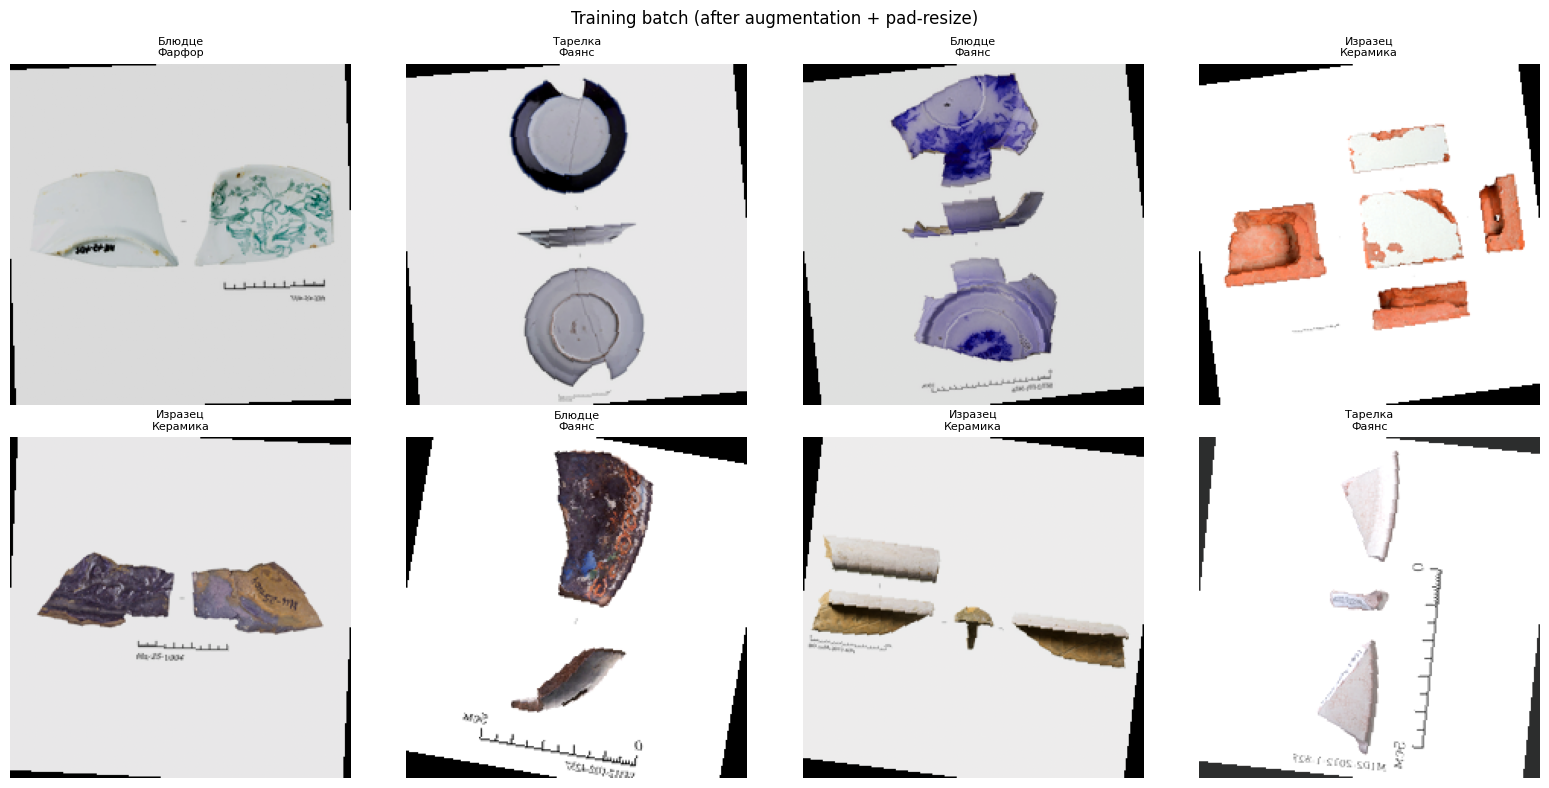

In [ ]:

class ArtifactDataset(Dataset):
    """
    Каждый элемент содержит: изображение, метку названия, метку материала, целевую маску и метаданные.
    target_mask: значение 1 там, где обе метки (название и материал) валидны, и 0 для неопределённых или пропущенных меток.
    Поддерживается аугментация описаний, если передано aug_descriptions.
    """
    def __init__(self, df: pd.DataFrame, transform=None,
                 aug_descriptions: dict | None = None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.aug_descriptions = aug_descriptions

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        name_label = int(name_le.transform([row["norm_name"]])[0])
        mat_label  = int(mat_le.transform([row["norm_material"]])[0])
        target_mask = 1 if row["quality_flag"] == "ok" else 0

        # случайный вариант описания
        desc = row.get("description", "")
        if self.aug_descriptions and row["code"] in self.aug_descriptions:
            alts = self.aug_descriptions[row["code"]]
            desc = random.choice(alts) if alts else desc

        meta = {
            "code":       row["code"],
            "image_file": row["image_file"],
            "group_key":  row["group_key"],
            "split":      row.get("split", ""),
            "description": desc,
        }
        return img, name_label, mat_label, target_mask, meta

aug_descriptions = {}
for row in df_clean[df_clean["split"] == "train_seed"].to_dict("records"):
    aug_descriptions[row["code"]] = aug.augment_description(row, n=5)

BATCH = 32

def make_loader(split_name, transform, shuffle=False, aug_desc=None):
    subset = df_clean[df_clean["split"] == split_name]
    ds = ArtifactDataset(subset, transform=transform,
                         aug_descriptions=aug_desc if shuffle else None)
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle,
                      num_workers=0, pin_memory=False)

train_loader = make_loader("train_seed", train_transform, shuffle=True,
                           aug_desc=aug_descriptions)
val_loader   = make_loader("val_gold",   val_transform)
test_loader  = make_loader("test_gold",  val_transform)
pool_loader  = make_loader("pool_candidate", val_transform)

imgs, name_lbs, mat_lbs, masks, metas = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}  dtype={imgs.dtype}")
print(f"name_labels : {name_lbs[:8].tolist()}  → {name_le.inverse_transform(name_lbs[:8].numpy()).tolist()}")
print(f"mat_labels  : {mat_lbs[:8].tolist()}   → {mat_le.inverse_transform(mat_lbs[:8].numpy()).tolist()}")
print(f"target_mask : {masks[:8].tolist()}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
denorm = T.Normalize(mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
                     std=[1/s for s in IMAGENET_STD])
for i, ax in enumerate(axes.flatten()):
    img_vis = denorm(imgs[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    name_str = name_le.inverse_transform([name_lbs[i].item()])[0]
    mat_str  = mat_le.inverse_transform([mat_lbs[i].item()])[0]
    ax.imshow(img_vis)
    ax.set_title(f"{name_str}\n{mat_str}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training batch (after augmentation + pad-resize)", fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/train_batch_sample.png", dpi=100)
plt.show()


## 9. Проверка протокола

In [ ]:

print("=" * 60)
print("PROTOCOL SANITY CHECKS")
print("=" * 60)

# 1. Пересечений между сплитами нет
split_groups = {s: set(df_clean[df_clean["split"] == s]["group_key"])
                for s in ["train_seed", "val_gold", "test_gold", "pool_candidate"]}
PASS = True
split_list = list(split_groups.keys())
for i in range(len(split_list)):
    for j in range(i+1, len(split_list)):
        a, b = split_list[i], split_list[j]
        overlap = split_groups[a] & split_groups[b]
        status = "✓ PASS" if not overlap else f"✗ FAIL (overlap={len(overlap)})"
        print(f"  {a} ∩ {b}: {status}")
        if overlap: PASS = False

# 2. Аугментации только в train
val_ds = ArtifactDataset(df_clean[df_clean["split"] == "val_gold"], transform=val_transform)
assert val_ds.transform == val_transform, "val uses train transform!"
print("  val/test use val_transform (no augmentation):  PASS")

# 3. Перепроверка путей для надёжности (пришлось в ручную удалять чб картинки)
bad_paths = df_clean[df_clean["image_exists"] == False]
print(f"  All image_path entries exist: {'PASS' if len(bad_paths)==0 else f'FAIL ({len(bad_paths)} missing)'}")

np.random.seed(SEED)
g1 = df_clean[df_clean["split"] == "train_seed"]["group_key"].iloc[0]
np.random.seed(SEED)
g2 = df_clean[df_clean["split"] == "train_seed"]["group_key"].iloc[0]
print(f"  Reproducible first train element: {'✓ PASS' if g1 == g2 else '✗ FAIL'}")

# 5. Метки пула не используются
print("  pool_candidate labels are in df_clean but withheld from all training steps:  PASS (by design)")

print(f"\n{'All checks passed!' if PASS else 'Some checks FAILED - review above'}")


PROTOCOL SANITY CHECKS
  train_seed ∩ val_gold: ✓ PASS
  train_seed ∩ test_gold: ✓ PASS
  train_seed ∩ pool_candidate: ✓ PASS
  val_gold ∩ test_gold: ✓ PASS
  val_gold ∩ pool_candidate: ✓ PASS
  test_gold ∩ pool_candidate: ✓ PASS
  val/test use val_transform (no augmentation): ✓ PASS
  All image_path entries exist: ✓ PASS
  Reproducible first train element: ✓ PASS
  pool_candidate labels are in df_clean but withheld from all training steps: ✓ PASS (by design)

✓ All checks passed!


## 10. Baseline модель

In [ ]:

class ArtifactModel(nn.Module):
    """
    EfficientNet-B0 с двумя классификационными головками:
    head_name - предсказание класса названия (основная цель), всего NUM_NAMES классов
    head_material - предсказание класса материала (вторичная цель), всего NUM_MATS классов

    Обе головки обучаются совместно с взвешенной функцией потерь.
    """
    def __init__(self, num_names: int, num_materials: int, dropout: float = 0.3):
        super().__init__()
        backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout)
        self.head_name     = nn.Linear(in_features, num_names)
        self.head_material = nn.Linear(in_features, num_materials)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.dropout(feat)
        return self.head_name(feat), self.head_material(feat), feat

model = ArtifactModel(NUM_NAMES, NUM_MATS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable:,}")

with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    logits_name, logits_mat, feats = model(dummy)
print(f"logits_name shape   : {logits_name.shape}   (B x {NUM_NAMES})")
print(f"logits_material shape: {logits_mat.shape}  (B x {NUM_MATS})")
print(f"embedding shape     : {feats.shape}         (B x 1280)")

# метрика: macro-F1 по norm_name
MAIN_METRIC = "macro_f1_name"
ALPHA = 0.7
BETA  = 0.3

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 69.9MB/s]


Total params    : 4,022,920
Trainable params: 4,022,920
logits_name shape   : torch.Size([4, 7])   (B x 7)
logits_material shape: torch.Size([4, 5])  (B x 5)
embedding shape     : torch.Size([4, 1280])         (B x 1280)


## 11. Обучение Baseline

In [ ]:

from PIL import Image
Image.MAX_IMAGE_PIXELS = None

def run_epoch(model, loader, optimizer=None, device=DEVICE):
    """Возвращает (потери, F1 по названию, F1 по материалу)"""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, all_name_true, all_name_pred, all_mat_true, all_mat_pred = 0, [], [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, name_lbs, mat_lbs, masks, _ in loader:
            imgs      = imgs.to(device)
            name_lbs  = name_lbs.to(device)
            mat_lbs   = mat_lbs.to(device)

            logits_n, logits_m, _ = model(imgs)
            loss_n = criterion(logits_n, name_lbs)
            loss_m = criterion(logits_m, mat_lbs)
            loss   = ALPHA * loss_n + BETA * loss_m

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            all_name_true.extend(name_lbs.cpu().numpy())
            all_name_pred.extend(logits_n.argmax(1).cpu().numpy())
            all_mat_true.extend(mat_lbs.cpu().numpy())
            all_mat_pred.extend(logits_m.argmax(1).cpu().numpy())

    avg_loss = total_loss / len(loader)
    name_f1  = f1_score(all_name_true, all_name_pred, average="macro", zero_division=0)
    mat_f1   = f1_score(all_mat_true,  all_mat_pred,  average="macro", zero_division=0)
    return avg_loss, name_f1, mat_f1

In [ ]:
# локальная копия датасета для спидов
import shutil
from pathlib import Path

LOCAL_IMG_DIR = Path("/content/dataset")
LOCAL_IMG_DIR.mkdir(exist_ok=True)

needed   = set(df_clean["image_file"].tolist())
existing = set(f.name for f in LOCAL_IMG_DIR.glob("*.jpg"))
to_copy  = needed - existing

if to_copy:
    print(f"Копируем {len(to_copy)} файлов в /content/ ...")
    for fname in tqdm(to_copy):
        src = IMG_DIR / fname
        if src.exists():
            shutil.copy2(src, LOCAL_IMG_DIR / fname)
    print("Готово")
else:
    print(f"Уже скопировано: {len(existing)} файлов")

df_clean["image_path"] = df_clean["image_file"].apply(lambda f: LOCAL_IMG_DIR / f)

def make_loader(split_name, transform, shuffle=False, aug_desc=None):
    subset = df_clean[df_clean["split"] == split_name]
    ds = ArtifactDataset(subset, transform=transform,
                         aug_descriptions=aug_desc if shuffle else None)
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader("train_seed", train_transform, shuffle=True,
                           aug_desc=aug_descriptions)
val_loader   = make_loader("val_gold",   val_transform)
test_loader  = make_loader("test_gold",  val_transform)
pool_loader  = make_loader("pool_candidate", val_transform)

# пути чекпоинтов
CKPT_PATH       = PROJECT_DIR / "artifacts/checkpoints/baseline_best.pt"
CKPT_DRIVE_BEST = DATA_DIR / "baseline_best.pt"          # лучший в Drive
CKPT_DRIVE_LAST = DATA_DIR / "checkpoint_last.pt"        # последний в Drive

SAVE_TO_DRIVE_EVERY = 3   # резервное сохранение каждые N эпох

# resume если чекпоинт в Drive
start_epoch = 1
best_val_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_name_f1": [], "val_mat_f1": []}

if CKPT_DRIVE_LAST.exists():
    ckpt = torch.load(CKPT_DRIVE_LAST, map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_val_f1 = ckpt.get("val_name_f1", 0.0)
    print(f"Resuming from epoch {start_epoch}, best F1={best_val_f1:.4f}")
else:
    print("Training from scratch")

EPOCHS = 25

for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_nf1, tr_mf1    = run_epoch(model, train_loader, optimizer)
    val_loss, val_nf1, val_mf1 = run_epoch(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_name_f1"].append(val_nf1)
    history["val_mat_f1"].append(val_mf1)

    # лучший чекпоинт
    if val_nf1 > best_val_f1:
        best_val_f1 = val_nf1
        payload = {
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "name_le": name_le,
            "mat_le":  mat_le,
            "val_name_f1": val_nf1,
            "val_mat_f1":  val_mf1,
        }
        torch.save(payload, CKPT_PATH)
        torch.save(payload, CKPT_DRIVE_BEST)
        star = " ★ best → Drive"
    else:
        star = ""

    # резервная копия
    if epoch % SAVE_TO_DRIVE_EVERY == 0:
        torch.save({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_name_f1": val_nf1,
        }, CKPT_DRIVE_LAST)
        star += f" | checkpoint → Drive (epoch {epoch})"

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"val_name_f1={val_nf1:.4f} | "
          f"val_mat_f1={val_mf1:.4f}{star}")

print(f"\nBest val macro-F1 (name): {best_val_f1:.4f}")
print(f"Checkpoint saved: {CKPT_DRIVE_BEST}")

Копируем 1330 файлов в /content/ ...


100%|██████████| 1330/1330 [03:59<00:00,  5.55it/s]

Готово
Training from scratch


Epoch   1/25 | train_loss=0.5462 | val_loss=0.7400 | val_name_f1=0.5690 | val_mat_f1=0.5157 ★ best → Drive
Epoch   2/25 | train_loss=0.4696 | val_loss=0.7084 | val_name_f1=0.5810 | val_mat_f1=0.5203 ★ best → Drive
Epoch   3/25 | train_loss=0.4357 | val_loss=0.6767 | val_name_f1=0.5920 | val_mat_f1=0.5091 ★ best → Drive | checkpoint → Drive (epoch 3)
Epoch   4/25 | train_loss=0.4013 | val_loss=0.6694 | val_name_f1=0.5885 | val_mat_f1=0.5270
Epoch   5/25 | train_loss=0.3556 | val_loss=0.6732 | val_name_f1=0.6018 | val_mat_f1=0.5093 ★ best → Drive
Epoch   6/25 | train_loss=0.3139 | val_loss=0.6483 | val_name_f1=0.6093 | val_mat_f1=0.5221 ★ best → Drive | checkpoint → Drive (epoch 6)
Epoch   7/25 | train_loss=0.3143 | val_loss=0.6483 | val_name_f1=0.5912 | val_mat_f1=0.5157
Epoch   8/25 | train_loss=0.2804 | val_loss=0.6405 | val_name_f1=0.6095 | val_mat_f1=0.5093 ★ best → Drive
Epoch   9/25 | train_loss=0.2709 | val_loss=0.6343 | val_name_f1=0.6164 | val_mat_f1=0.4966 ★ best → Drive | che

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

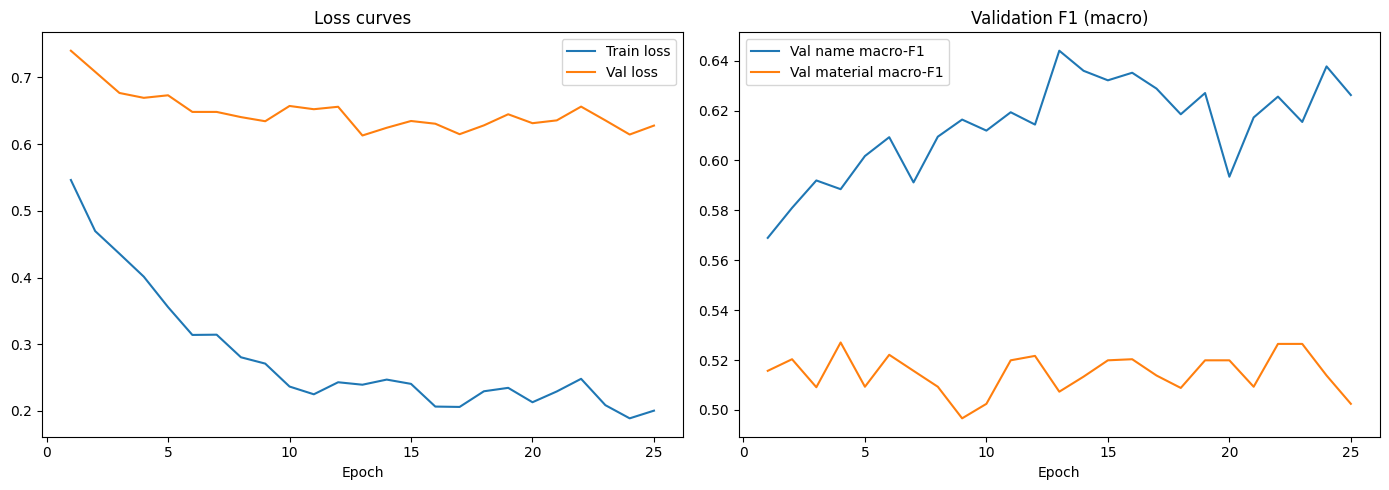


Baseline Classification Report (name):
              precision    recall  f1-score   support

      Блюдце       0.69      0.55      0.61        20
     Игрушка       0.00      0.00      0.00         0
     Изразец       0.86      1.00      0.93        25
      Крышка       0.70      0.78      0.74         9
       Миска       0.79      0.79      0.79        14
      Плитка       0.00      0.00      0.00         1
     Тарелка       0.80      0.80      0.80        46

    accuracy                           0.79       115
   macro avg       0.55      0.56      0.55       115
weighted avg       0.78      0.79      0.78       115



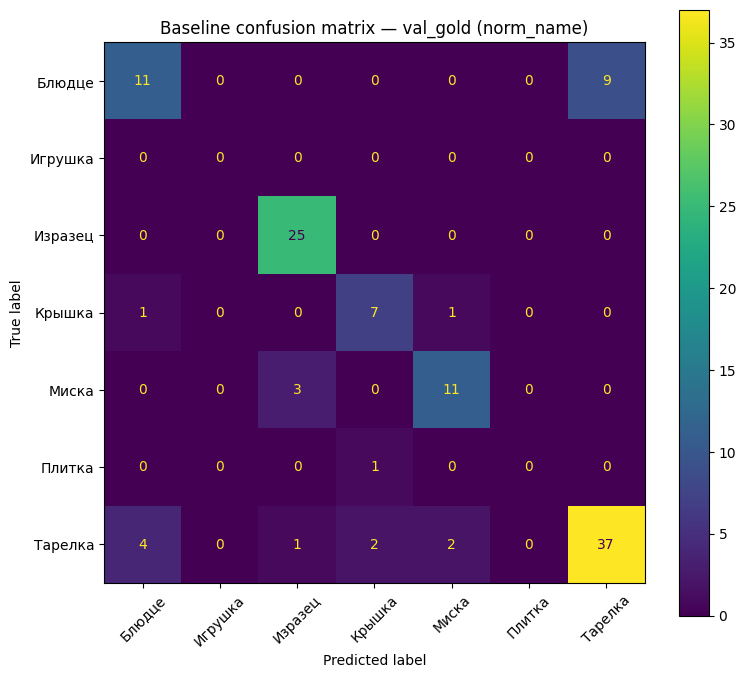


Baseline val macro-F1 (name): 0.6440  ← origin for all comparisons


In [ ]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train loss")
axes[0].plot(epochs_range, history["val_loss"],   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["val_name_f1"], label="Val name macro-F1")
axes[1].plot(epochs_range, history["val_mat_f1"],  label="Val material macro-F1")
axes[1].set_title("Validation F1 (macro)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/baseline_learning_curves.png", dpi=100)
plt.show()

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for imgs, name_lbs, _, _, _ in val_loader:
        logits_n, _, _ = model(imgs.to(DEVICE))
        all_true.extend(name_lbs.numpy())
        all_pred.extend(logits_n.argmax(1).cpu().numpy())

print("\nBaseline Classification Report (name):")
print(classification_report(all_true, all_pred,
                             labels=list(range(len(name_le.classes_))),
                             target_names=name_le.classes_,
                             zero_division=0))
cm = confusion_matrix(all_true, all_pred, labels=list(range(len(name_le.classes_))))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=name_le.classes_).plot(ax=ax, xticks_rotation=45)
ax.set_title("Baseline confusion matrix - val_gold (norm_name)")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/baseline_confusion_matrix.png", dpi=100)
plt.show()

BASELINE_F1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
print(f"\nBaseline val macro-F1 (name): {BASELINE_F1:.4f}  ← origin for all comparisons")

In [ ]:
import pickle
from google.colab import files

with open("/content/name_le.pkl", "wb") as f:
    pickle.dump(name_le, f)
with open("/content/mat_le.pkl", "wb") as f:
    pickle.dump(mat_le, f)

files.download(str(CKPT_DRIVE_BEST))   # baseline_best.pt
files.download("/content/name_le.pkl")
files.download("/content/mat_le.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Uncertainty Signals

Uncertainty: 100%|██████████| 14/14 [00:51<00:00,  3.67s/it]


Uncertainty stats on pool_candidate:
         max_prob     entropy      margin
count  434.000000  434.000000  434.000000
mean     0.788655    0.575703    0.642321
std      0.188715    0.405706    0.318029
min      0.285316    0.005226    0.000559
25%      0.636611    0.214300    0.367081
50%      0.852688    0.536962    0.746271
75%      0.958249    0.902989    0.927275
max      0.999458    1.693476    0.999136

Top-10 most uncertain (highest entropy):
                 code true_name pred_name  max_prob   entropy    margin
111        Нц-33-5144   Тарелка   Тарелка  0.358302  1.693476  0.184841
319  Нейш3А-2018-3690    Блюдце     Миска  0.285316  1.631359  0.031212
320  Нейш3А-2018-3692   Игрушка    Крышка  0.392718  1.630692  0.182436
377  Нейш3А-2018-5893   Тарелка   Тарелка  0.398355  1.538180  0.160106
307  Нейш3А-2018-2807    Крышка   Тарелка  0.360410  1.506646  0.034451
61    КБ-2014-Р3-0342   Изразец    Крышка  0.364070  1.459998  0.108289
29      Нев11-Г04-185   Тарелка   Израз

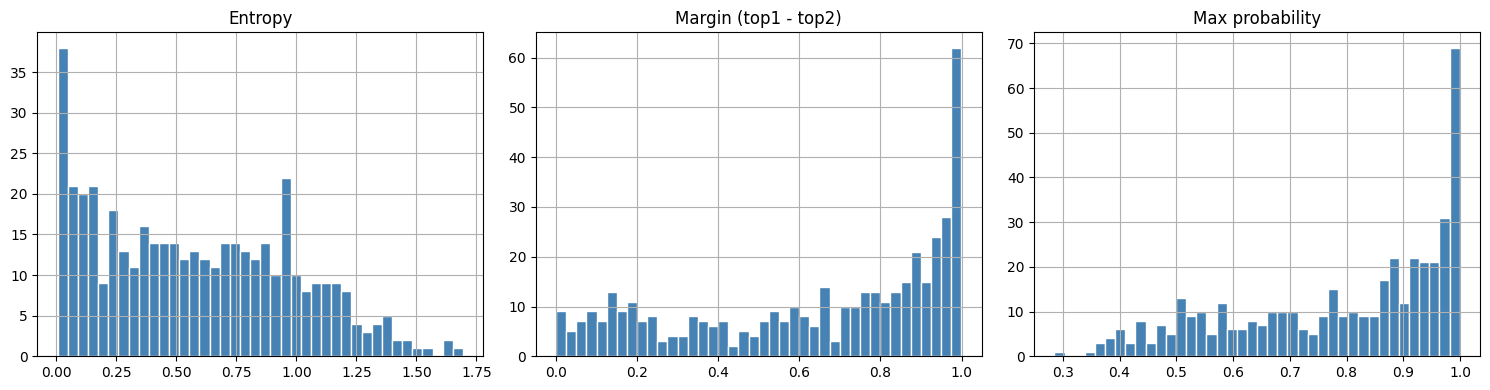

In [ ]:

def compute_uncertainty(model, loader, device=DEVICE):
    """Вычисляемс max-prob (максимальную вероятность), entropy (энтропию) и margin (разницу между двумя самыми вероятными классами) для каждого образца в загрузчике"""
    model.eval()
    records = []
    with torch.no_grad():
        for imgs, name_lbs, mat_lbs, masks, metas in tqdm(loader, desc="Uncertainty"):
            logits_n, logits_m, _ = model(imgs.to(device))
            probs = F.softmax(logits_n, dim=1).cpu().numpy()
            for i in range(len(imgs)):
                p = probs[i]
                top2 = np.sort(p)[::-1]
                records.append({
                    "code":             metas["code"][i],
                    "image_file":       metas["image_file"][i],
                    "group_key":        metas["group_key"][i],
                    "true_name":        name_le.inverse_transform([name_lbs[i].item()])[0],
                    "pred_name":        name_le.inverse_transform([probs[i].argmax()])[0],
                    "max_prob":         float(top2[0]),
                    "entropy":          float(-np.sum(p * np.log(p + 1e-10))),
                    "margin":           float(top2[0] - top2[1]),
                    "confidence":       float(top2[0]),
                    "uncertainty_score": float(-np.sum(p * np.log(p + 1e-10))),  # entropy
                })
    return pd.DataFrame(records)

# для pool_candidate
df_pool_unc = compute_uncertainty(model, pool_loader)
df_pool_unc.to_csv(PROJECT_DIR / "artifacts/active_learning/pool_uncertainty.csv", index=False)

print("Uncertainty stats on pool_candidate:")
print(df_pool_unc[["max_prob", "entropy", "margin"]].describe())

# топ-10 неопределённых
print("\nTop-10 most uncertain (highest entropy):")
print(df_pool_unc.nlargest(10, "entropy")[
    ["code", "true_name", "pred_name", "max_prob", "entropy", "margin"]].to_string())

# топ-10 уверенных
print("\nTop-10 most confident (highest max_prob):")
print(df_pool_unc.nsmallest(10, "entropy")[
    ["code", "true_name", "pred_name", "max_prob", "entropy", "margin"]].to_string())

# сравнение сигналов
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["entropy", "margin", "max_prob"],
                          ["Entropy", "Margin (top1 - top2)", "Max probability"]):
    df_pool_unc[col].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/reports/uncertainty_distributions.png", dpi=100)
plt.show()


## 13. Embedding Space и анализ разнообразия

Embeddings: 100%|██████████| 21/21 [02:03<00:00,  5.90s/it]


Pool embeddings shape : (434, 1280)
Train embeddings shape: (655, 1280)

3 examples with nearest neighbors:
  Query: М102-2012-2-0538 | NNs: ['КБ-2014-Р3-0105', 'Нейш3А-2018-0833', 'Нейш3А-2018-4751'] | dists: [0.199 0.223 0.229]
  Query: М102-2012-2-1181 | NNs: ['Нц-33-0072', 'Т-12-Р3-1578', 'М102-2012-2-1327'] | dists: [0.291 0.304 0.327]
  Query: КБ-2014-Р3-0138 | NNs: ['КБ-2014-Р3-0070', 'Нейш3А-2018-7185', 'Нейш3А-2018-5182'] | dists: [0.172 0.237 0.253]


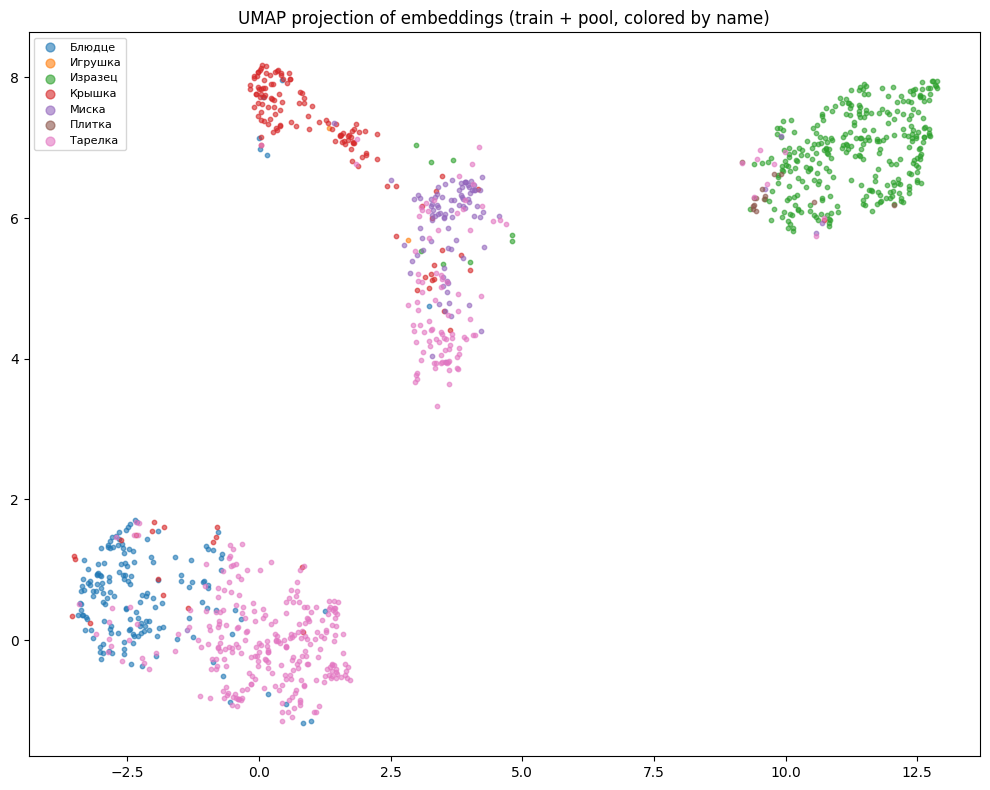

UMAP projection saved.


In [ ]:

def extract_embeddings(model, loader, device=DEVICE):
    model.eval()
    embs, codes, labels = [], [], []
    with torch.no_grad():
        for imgs, name_lbs, _, _, metas in tqdm(loader, desc="Embeddings"):
            _, _, feat = model(imgs.to(device))
            embs.append(feat.cpu().numpy())
            codes.extend(metas["code"])
            labels.extend(name_lbs.numpy())
    embs   = np.vstack(embs)
    labels = np.array(labels)
    return embs, codes, labels

# эмбеддинги pool + train
pool_embs, pool_codes, pool_labels = extract_embeddings(model, pool_loader)
train_embs, train_codes, train_labels = extract_embeddings(model, train_loader)

print(f"Pool embeddings shape : {pool_embs.shape}")
print(f"Train embeddings shape: {train_embs.shape}")

# нормализация для cosine
pool_embs_n  = pool_embs  / (np.linalg.norm(pool_embs,  axis=1, keepdims=True) + 1e-10)
train_embs_n = train_embs / (np.linalg.norm(train_embs, axis=1, keepdims=True) + 1e-10)

# ближайшие соседи (diversity sampling)
nn_model = NearestNeighbors(n_neighbors=6, metric="cosine")
nn_model.fit(pool_embs_n)
distances, indices = nn_model.kneighbors(pool_embs_n)

print("\n3 examples with nearest neighbors:")
for idx in [0, 10, 50]:
    if idx < len(pool_codes):
        nn_codes = [pool_codes[i] for i in indices[idx][1:4]]
        print(f"  Query: {pool_codes[idx]} | NNs: {nn_codes} | dists: {distances[idx][1:4].round(3)}")

# UMAP / t-SNE (нужен umap-learn)
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15)
    all_embs = np.vstack([train_embs_n, pool_embs_n])
    all_labels = np.concatenate([train_labels, pool_labels])
    embs_2d = reducer.fit_transform(all_embs)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_idx, cls_name in enumerate(name_le.classes_):
        mask = all_labels == cls_idx
        ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1], label=cls_name, s=10, alpha=0.6)
    ax.legend(fontsize=8, markerscale=2)
    ax.set_title("UMAP projection of embeddings (train + pool, colored by name)")
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "artifacts/reports/umap_embeddings.png", dpi=100)
    plt.show()
    print("UMAP projection saved.")
except ImportError:
    print("umap-learn not installed. Skipping UMAP. Install with: pip install umap-learn")


## 14. Подозрительные примеры и таблица ревью

In [ ]:

# объединить uncertainty и visual flags
pool_df = df_clean[df_clean["split"] == "pool_candidate"].copy()
df_review = pool_df.merge(df_pool_unc[["code", "pred_name", "confidence",
                                        "uncertainty_score", "entropy", "margin"]],
                          on="code", how="left")

def get_visual_flags(path):
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        h, w = arr.shape[:2]
        white = np.all(arr > 240, axis=2)
        fg_ratio = 1.0 - white.mean()
        aspect = w / h
        layout = "multi-view" if (aspect > 1.8 or aspect < 0.55) else "single-view"
        return {"layout_mode": layout, "fg_ratio": round(fg_ratio, 3),
                "bg_type": "white", "has_scale_bar": True, "has_overlay_text": False}
    except Exception:
        return {"layout_mode": "unknown", "fg_ratio": 0.0,
                "bg_type": "unknown", "has_scale_bar": False, "has_overlay_text": False}

print("Computing visual flags for pool ...")
vis_flags = [get_visual_flags(p) for p in tqdm(df_review["image_path"])]
df_vis_flags = pd.DataFrame(vis_flags)
for col in df_vis_flags.columns:
    df_review[col] = df_vis_flags[col].values

def reason_flag(row):
    reasons = []
    if pd.notna(row.get("uncertainty_score")) and row["uncertainty_score"] > 1.5:
        reasons.append("high_entropy")
    if row.get("norm_name") != row.get("pred_name"):
        reasons.append("label_model_disagree")
    if row.get("fg_ratio", 1) < 0.08:
        reasons.append("tiny_foreground")
    if row.get("layout_mode") == "multi-view":
        reasons.append("multi_view_card")
    if row.get("quality_flag") == "uncertain":
        reasons.append("uncertain_label")
    return "|".join(reasons) if reasons else "ok"

df_review["reason_flag"] = df_review.apply(reason_flag, axis=1)

# сортировка по подозрительности
df_review["suspicion_score"] = (
    df_review["uncertainty_score"].fillna(0) * 0.5 +
    (df_review["norm_name"] != df_review["pred_name"]).astype(float) * 1.0 +
    (1 - df_review["fg_ratio"].fillna(0.5)) * 0.3
)
df_review = df_review.sort_values("suspicion_score", ascending=False)

REVIEW_COLS = ["image_file", "group_key", "norm_name", "pred_name",
               "confidence", "uncertainty_score", "reason_flag",
               "layout_mode", "bg_type", "fg_ratio",
               "has_scale_bar", "has_overlay_text"]

review_table = df_review[REVIEW_COLS].head(50)
review_table.to_csv(PROJECT_DIR / "artifacts/review/review_table.csv", index=False)
print(f"\nReview table (top 50):")
print(review_table.head(30).to_string())


Computing visual flags for pool ...


100%|██████████| 434/434 [04:12<00:00,  1.72it/s]


Review table (top 50):
                    image_file    group_key norm_name pred_name  confidence  uncertainty_score                                        reason_flag  layout_mode bg_type  fg_ratio  has_scale_bar  has_overlay_text
320  Нейш3А-2018-3692_orig.jpg  Нейш3А-2018   Игрушка    Крышка    0.392718           1.630692                  high_entropy|label_model_disagree  single-view   white     0.341           True             False
29      Нев11-Г04-185_orig.jpg    Нев11-Г04   Тарелка   Изразец    0.471968           1.446657               label_model_disagree|multi_view_card   multi-view   white     0.095           True             False
307  Нейш3А-2018-2807_orig.jpg  Нейш3А-2018    Крышка   Тарелка    0.360410           1.506646  high_entropy|label_model_disagree|multi_view_card   multi-view   white     0.244           True             False
319  Нейш3А-2018-3690_orig.jpg  Нейш3А-2018    Блюдце     Миска    0.285316           1.631359                  high_entropy|label_model

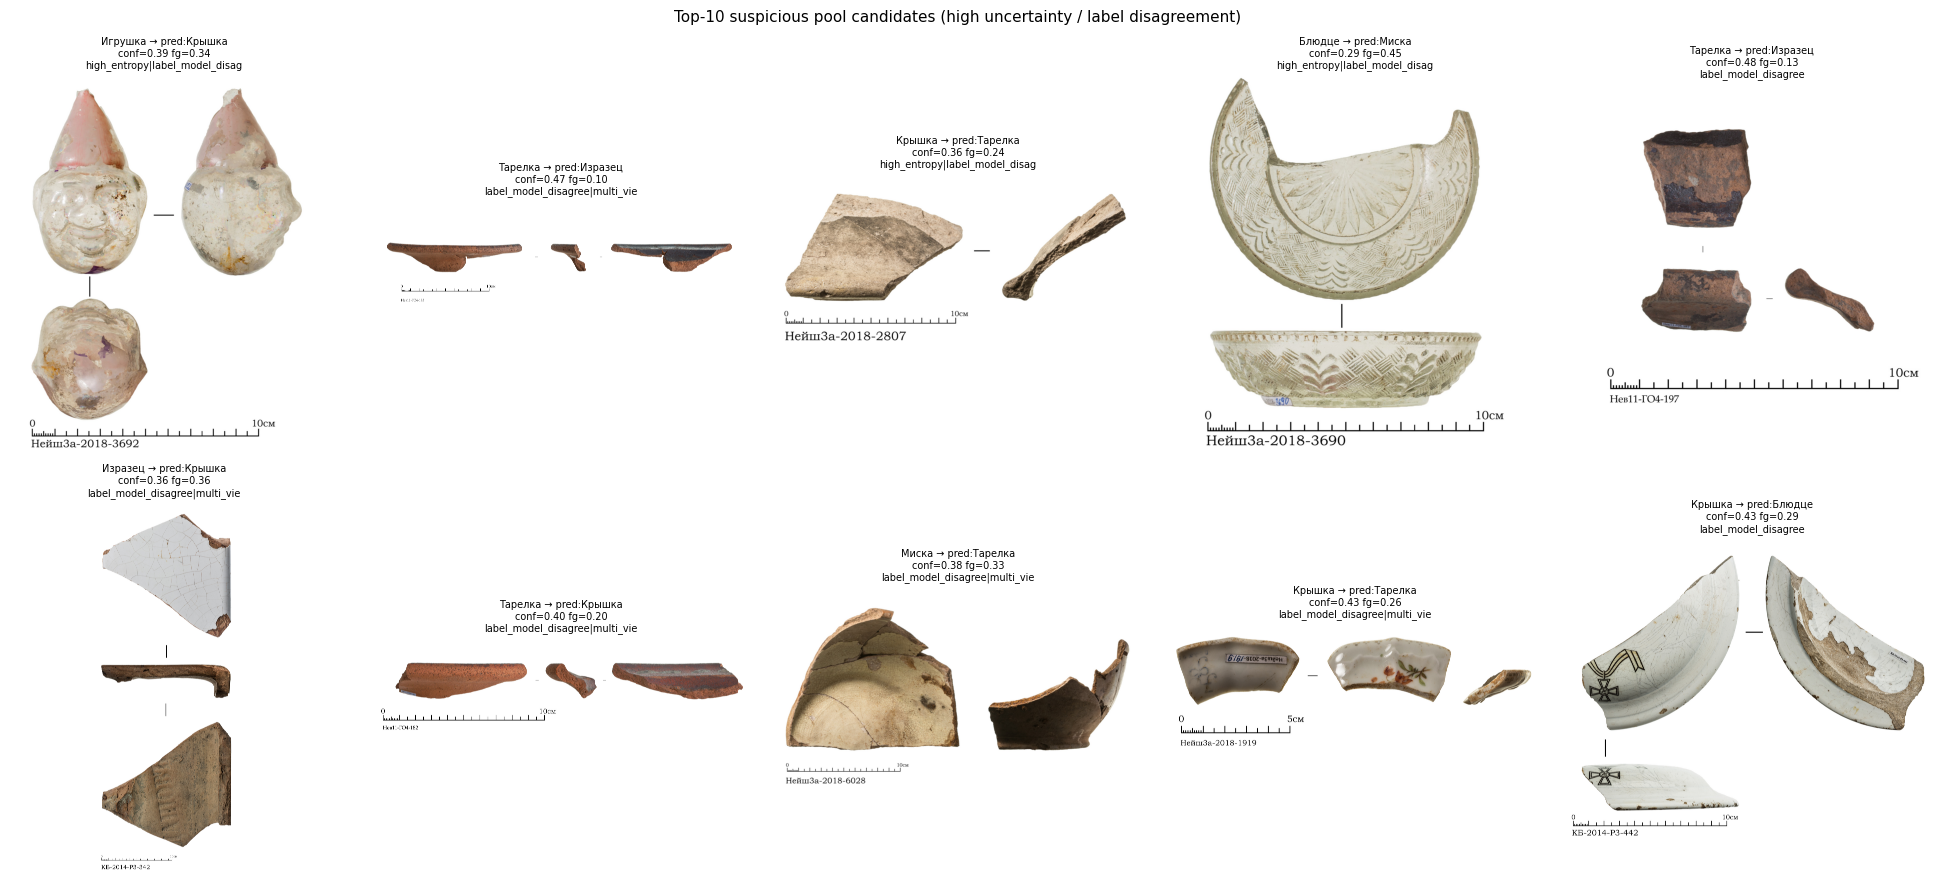


Reason flag breakdown:
reason_flag
ok                                                      158
multi_view_card                                         124
label_model_disagree                                     72
label_model_disagree|multi_view_card                     60
uncertain_label                                           6
label_model_disagree|uncertain_label                      3
multi_view_card|uncertain_label                           3
label_model_disagree|multi_view_card|uncertain_label      2
high_entropy|label_model_disagree                         2
high_entropy|label_model_disagree|multi_view_card         1
high_entropy                                              1
high_entropy|uncertain_label                              1
tiny_foreground                                           1
Name: count, dtype: int64
  Нейш3А-2018-3692_orig.jpg                     → probable_label_noise
  Нев11-Г04-185_orig.jpg                        → visual_nuisance_artifact
  Нейш3А-201

In [ ]:

top10 = df_review.head(10)
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for ax, (_, row) in zip(axes.flatten(), top10.iterrows()):
    try:
        img = Image.open(row["image_path"])
        ax.imshow(img)
    except Exception:
        ax.set_facecolor("lightgray")
    title = (f"{row['norm_name']} → pred:{row.get('pred_name', '?')}\n"
             f"conf={row.get('confidence', 0):.2f} fg={row.get('fg_ratio', 0):.2f}\n"
             f"{row.get('reason_flag', '')[:30]}")
    ax.set_title(title, fontsize=7)
    ax.axis("off")
plt.suptitle("Top-10 suspicious pool candidates (high uncertainty / label disagreement)", fontsize=11)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "artifacts/review/flagged_examples.png", dpi=100)
plt.show()

print("\nReason flag breakdown:")
print(df_review["reason_flag"].value_counts().head(15))

for _, row in df_review.head(15).iterrows():
    flags = row.get("reason_flag", "")
    if "multi_view_card" in flags or "tiny_foreground" in flags:
        category = "visual_nuisance_artifact"
    elif "label_model_disagree" in flags and "high_entropy" in flags:
        category = "probable_label_noise"
    else:
        category = "genuinely_hard"
    print(f"  {row['image_file'][:40]:45s} → {category}")


## 15. Random Sampling

In [ ]:

BUDGET = 50   # Fixed budget for all strategies

def random_sampling(pool_df: pd.DataFrame, budget: int, seed: int = SEED) -> pd.DataFrame:
    """Выбрать budget групп случайным образом из пула кандидатов (с учётом группировки, воспроизводимо)."""
    rng = np.random.RandomState(seed)
    unique_groups = pool_df["group_key"].unique()
    rng.shuffle(unique_groups)
    selected_groups = unique_groups[:budget]
    queried = pool_df[pool_df["group_key"].isin(selected_groups)]
    return queried

pool_df = df_clean[df_clean["split"] == "pool_candidate"].copy()
random_queried = random_sampling(pool_df, BUDGET)

print(f"Random sampling: {len(random_queried['group_key'].unique())} unique groups, "
      f"{len(random_queried)} images queried")
print(f"Label distribution of queried set:")
print(random_queried["norm_name"].value_counts())

# сохранить IDs
random_queried[["code", "image_file", "group_key", "norm_name"]].to_csv(
    PROJECT_DIR / "artifacts/active_learning/random_queried.csv", index=False)

# проверка воспроизводимости
random_queried_2 = random_sampling(pool_df, BUDGET, seed=SEED)
assert list(random_queried["code"]) == list(random_queried_2["code"]), "Reproducibility FAIL"
print("Reproducibility check: ✓ PASS (same seed → same selection)")


Random sampling: 15 unique groups, 434 images queried
Label distribution of queried set:
norm_name
Тарелка    183
Блюдце      85
Крышка      70
Изразец     61
Миска       30
Плитка       4
Игрушка      1
Name: count, dtype: int64
Reproducibility check: ✓ PASS (same seed → same selection)


## 16. Uncertainty Sampling

In [ ]:

def uncertainty_sampling(pool_df: pd.DataFrame, uncertainty_df: pd.DataFrame,
                         budget: int, signal: str = "entropy") -> pd.DataFrame:
    """
    Выбрать группы по бюджету с наибольшей неопределённостью
    Учитывать групповую структуру: сначала выбрать самое плохое изображение внутри каждой группы
    Затем отсортировать группы по рангу и взять уникальные группы в пределах бюджета
    """
    merged = pool_df.merge(uncertainty_df[["code", signal]], on="code", how="left")
    # max uncertainty на группу
    group_unc = merged.groupby("group_key")[signal].max().reset_index()
    group_unc = group_unc.sort_values(signal, ascending=False)
    top_groups = group_unc.head(budget)["group_key"]
    return pool_df[pool_df["group_key"].isin(top_groups)]

unc_queried = uncertainty_sampling(pool_df, df_pool_unc, BUDGET, signal="entropy")

print(f"Uncertainty sampling: {len(unc_queried['group_key'].unique())} groups, "
      f"{len(unc_queried)} images")
print(f"Label distribution:")
print(unc_queried["norm_name"].value_counts())

unc_queried[["code", "image_file", "group_key", "norm_name"]].to_csv(
    PROJECT_DIR / "artifacts/active_learning/uncertainty_queried.csv", index=False)

rnd_groups = set(random_queried["group_key"])
unc_groups = set(unc_queried["group_key"])
overlap    = rnd_groups & unc_groups

print(f"\nOverlap between random and uncertainty selections: {len(overlap)} / {BUDGET}")
print(f"Unique to uncertainty: {len(unc_groups - rnd_groups)}")

top10_unc = df_pool_unc[df_pool_unc["code"].isin(unc_queried["code"])].nlargest(10, "entropy")
print("\nTop-10 highest-entropy objects selected by uncertainty sampling:")
print(top10_unc[["code", "true_name", "pred_name", "entropy", "margin"]].to_string())


Uncertainty sampling: 15 groups, 434 images
Label distribution:
norm_name
Тарелка    183
Блюдце      85
Крышка      70
Изразец     61
Миска       30
Плитка       4
Игрушка      1
Name: count, dtype: int64

Overlap between random and uncertainty selections: 15 / 50
Unique to uncertainty: 0

Top-10 highest-entropy objects selected by uncertainty sampling:
                 code true_name pred_name   entropy    margin
111        Нц-33-5144   Тарелка   Тарелка  1.693476  0.184841
319  Нейш3А-2018-3690    Блюдце     Миска  1.631359  0.031212
320  Нейш3А-2018-3692   Игрушка    Крышка  1.630692  0.182436
377  Нейш3А-2018-5893   Тарелка   Тарелка  1.538180  0.160106
307  Нейш3А-2018-2807    Крышка   Тарелка  1.506646  0.034451
61    КБ-2014-Р3-0342   Изразец    Крышка  1.459998  0.108289
29      Нев11-Г04-185   Тарелка   Изразец  1.446657  0.255035
405      Т-12-Р3-1093   Тарелка   Тарелка  1.409564  0.022182
385  Нейш3А-2018-6028     Миска   Тарелка  1.402071  0.120797
31      Нев11-Г04-197   

## 17. Hybrid Strategy (k-Center Coreset)

In [ ]:

def coreset_sampling(pool_embs: np.ndarray, pool_codes: list,
                     pool_df: pd.DataFrame, train_embs: np.ndarray,
                     budget: int) -> pd.DataFrame:
    """
    k-Center Coreset (корсет для задачи k-центров) - это небольшое подмножество данных, выбранное из большого исходного набора, которое с высокой точностью аппроксимирует структуру исходных данных для задачи кластеризации k-центров
    """
    # Normalize
    pe = pool_embs / (np.linalg.norm(pool_embs, axis=1, keepdims=True) + 1e-10)
    te = train_embs / (np.linalg.norm(train_embs, axis=1, keepdims=True) + 1e-10)

    # мин. расстояние до labeled set
    # cosine distance = 1 - dot-product
    sim = pe @ te.T                              # (pool_N, train_N)
    min_dist = 1.0 - sim.max(axis=1)            # (pool_N,)

    selected_indices = []
    covered_groups   = set()
    code_to_group    = dict(zip(pool_df["code"], pool_df["group_key"]))

    for _ in range(budget * 3):
        if len(selected_indices) >= budget:
            break
        idx = int(np.argmax(min_dist))
        code = pool_codes[idx]
        gk   = code_to_group.get(code, code)
        if gk in covered_groups:
            min_dist[idx] = -1
            continue
        selected_indices.append(idx)
        covered_groups.add(gk)
        # обновить min_dist
        new_sim = pe @ pe[idx:idx+1].T
        new_dist = 1.0 - new_sim.squeeze()
        min_dist = np.minimum(min_dist, new_dist)

    sel_codes = [pool_codes[i] for i in selected_indices]
    return pool_df[pool_df["code"].isin(sel_codes)]

diversity_queried = coreset_sampling(pool_embs, pool_codes, pool_df, train_embs, BUDGET)

print(f"Coreset (diversity) sampling: {len(diversity_queried['group_key'].unique())} groups, "
      f"{len(diversity_queried)} images")
print(f"Label distribution:")
print(diversity_queried["norm_name"].value_counts())

diversity_queried[["code", "image_file", "group_key", "norm_name"]].to_csv(
    PROJECT_DIR / "artifacts/active_learning/diversity_queried.csv", index=False)

def mean_pairwise_distance(codes, embs_norm, all_codes):
    idx = [all_codes.index(c) for c in codes if c in all_codes]
    if len(idx) < 2: return 0.0
    sub = embs_norm[idx]
    sim = sub @ sub.T
    np.fill_diagonal(sim, -1)
    dists = 1 - sim.max(axis=1)
    return float(dists.mean())

pool_codes_list = list(pool_codes)
pool_embs_n_full = pool_embs / (np.linalg.norm(pool_embs, axis=1, keepdims=True) + 1e-10)

rnd_div = mean_pairwise_distance(list(random_queried["code"]),   pool_embs_n_full, pool_codes_list)
unc_div = mean_pairwise_distance(list(unc_queried["code"]),      pool_embs_n_full, pool_codes_list)
div_div = mean_pairwise_distance(list(diversity_queried["code"]),pool_embs_n_full, pool_codes_list)

print(f"\nMean pairwise distance (higher = more diverse):")
print(f"  Random      : {rnd_div:.4f}")
print(f"  Uncertainty : {unc_div:.4f}")
print(f"  Coreset     : {div_div:.4f}")


Coreset (diversity) sampling: 12 groups, 12 images
Label distribution:
norm_name
Тарелка    4
Изразец    3
Плитка     2
Крышка     1
Миска      1
Блюдце     1
Name: count, dtype: int64

Mean pairwise distance (higher = more diverse):
  Random      : 0.2558
  Uncertainty : 0.2558
  Coreset     : 0.5346


Проблемы в данных:

- Путаница в разметке: категория "Тарелка/блюдо" неоднозначна - её нужно разделить или объединить
- Есть записи "Миска (?)" со знаком вопроса - это признак неуверенности куратора

- Некоторые классы слишком редкие
- "Игрушка ёлочная" всего в одном экземпляре - обучиться по одному примеру невозможно
- Материалы вроде дерева или камня встречаются реже 5 раз - такие классы лучше объединить или удалить

- Много фотографий плохого качества (некоторые былии вообще чёрный объект на белом фоне - чистилось вручную)
- Если доля объекта на фото (fg_ratio) меньше 0.05, изображение почти полностью состоит из белого фона и линейки масштаба
- В таких условиях модель не может выделить полезные признаки артефакта

- На одной карточке часто снято сразу 2–5 проекций одного объекта

- Лучше использовать паддинг с изменением размера по длинной стороне

- Крупные планы на той же карточке визуально сильно отличаются от общих видов

- Шкала с линейкой присутствует на всех снимках
- Модель может выучить "положение линейки" как случайный признак
- Рекомендуется маскировать или обрезать зону линейки

- В описаниях материалов встречаются синонимы
- "Красноглиняная керамика", "Керамика", "Глина" - всё это практически одно и то же
- После нормализации они схлопнулись в 5 классов, но это лучше исправить прямо в исходной базе

Рекомендации куратору:

- Привести словарь материалов к единому стандарту
- Объединить варианты вроде Красноглиняная / Белоглиняная в просто "Керамика"

- Решить судьбу класса "Тарелка/блюдо" - либо объединить в "Тарелку", либо ввести отдельную чёткую категорию

- Отказаться от слепой обрезки по центру
- Вместо этого использовать предобработку с выравниванием по длинной стороне и добелением

- Запретить аугментации типа мозаики или CutMix между разными артефактами

- Добавить метаданные по каждому изображению: тип компоновки, наличие шкалы, доля объекта

- Сначала переразметить топ-50 примеров с самой высокой энтропией

- Для активного обучения лучше использовать coreset или гибридную стратегию
- Чистая неопределённость (uncertainty) плохо подходит - она чаще выбирает карточки с крошечным объектом и несколькими проекциями, а не настоящий шум в разметке

- Новые фото нужнее всего для классов с малым числом примеров
- "Игрушка" (всего 7 снимков)
- "Плитка" (26 снимков)